In [1]:
# 05.09.2026 - 20260905a.ipynb: ODTWORZENIE WYNIKU Z SEKCJI 4 ARTYKULU,
# TYM RAZEM NA SIATCE t0, KTOREJ UZYWA ARTYKUL.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PO CO. 24.08 (20260824f.ipynb, dziennik 20260824.txt pkt 14) odtworzylismy
# piate minimum sekcji 4 - to bylo pierwsze i jedyne miejsce, w ktorym nasz
# pipeline zgodzil sie z opublikowana liczba. Prezentacja ma sie na tym oprzec,
# wiec (a) powtarzamy tamten wynik od zera, (b) rozszerzamy go na pozostale
# cztery opublikowane punkty w sposob, ktory da sie obronic.
#
# CO SIE ZMIENIA WZGLEDEM POPRZEDNICH PROB. Wszystkie nasze dotychczasowe skany
# (20260824f, 20260826d i wszystko, co z nich korzysta) chodza po siatce co 6 h
# zakotwiczonej na polnocy - fazy 00:00 / 06:00 / 12:00 / 18:00. Artykul podaje
# wszystkie piec swoich t0 z ta sama godzina 07:37:12 GMT. Nasza siatka NIGDY w
# ten punkt nie trafia; najblizszy jej wezel lezy 1 h 37 min obok. Artykul sam
# ostrzega (podpis Fig. 2, sekcja 3), ze PPDF jest wrazliwe na przesuniecia
# mniejsze niz szerokosc kosza, a sekcja 4 mowi to wprost:
#
#   "the specific fraction of the five-days period at which we begin the
#    scanning procedure is an effect of the optimization applied already to the
#    'burning sample' of the data, so in the other data set the only factor
#    that penalizes a specific probability value is related to the number of
#    steps in t0 available as new trials"
#
# Czyli: w sekcji 4 faza wewnatrz kosza jest USTALONA (odziedziczona z sekcji
# 3), a nowe proby to CALE kroki 5-dniowe. Siatka t0 sekcji 4 jest wiec krata
# co 5 dni o fazie 07:37:12 - 20 razy rzadsza niz nasza siatka 6 h. To ma dwa
# skutki, oba sprawdzane w tym notebooku: nasze skany nigdy nie policzyly
# punktow artykulu, i nasze skany mialy 20 razy wiecej prob niz artykul.
#
# JAKA IMPLEMENTACJA STATYSTYKI. Wylacznie referencyjna `cosmoseismic_stat`,
# przepisana znak w znak z 20260824f.ipynb - ta, ktora dala zgodnosc z
# artykulem i ktora policzyla wszystkie pliki finetune_*.csv. Szybka wersja
# wektorowa z 20260903/20260904 NIE jest tu uzywana do zadnego wyniku; komorka
# 1 pokazuje, dlaczego (nie sa wymienne co do bitu) i o ile sie roznia.
#
# KOSZT. Krata artykulu ma ~3,7 tys. punktow zamiast 74 322, wiec stac nas na
# wersje referencyjna wszedzie. Najdrozsza jest komorka 2 (powtorka skanu z
# 24.08, 13 153 punkty, ~30-60 s rownolegle na 20 rdzeniach); reszta to
# lacznie kilkadziesiat sekund.
#
# WEJSCIA:
#   ../data/mosc_data.csv                          (NMDB, Moskwa, co 6 h)
#   ../data/usgs_data/usgs_m4_1965_2025.csv        (USGS, M >= 4,0)
#   ../data/SN_m_tot_V2.0.csv                      (SILSO, plamy sloneczne)
#   ../results/finetune_mosc_P3350_d5_dt15_scan.csv        (skan z 24.08)
#   ../results/finetune_mosc_P3350_d5_dt15_fullhistory.csv (skan z 26.08)
# WYJSCIA: ../results/replikacja_*.csv i ../results/replikacja_*_{pl,en}.png
import sys
import time

import numpy as np
import pandas as pd
from scipy.stats import binom, norm, chi2
from scipy.signal import find_peaks

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

RESULTS_DIR = "../results"
MOSC_PATH = "../data/mosc_data.csv"
USGS_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"
SUNSPOT_PATH = "../data/SN_m_tot_V2.0.csv"

# Parametry sekcji 4 - dokladnie te, ktore 24.08 daly zgodnosc z artykulem.
P_DAYS = 3350       # dlugosc okna analizy
D_DAYS = 5          # szerokosc kosza
M_THRESHOLD = 4.0   # prog magnitudy
DT_DAYS = 15        # przesuniecie EQ wzgledem CR (przepis artykulu, NIE nasze dt=0)

# Granica "burning sample" - pierwszy rekord Augera, sekcja 3 artykulu.
BURNING_START = pd.Timestamp("2005-03-30")

# Piec minimow sekcji 4. PPDF brane z WZORU ILOCZYNU (str. 5), bo ma wiecej
# cyfr znaczacych niz proza akapit wyzej (3,3e-8 vs 3,34e-8 itd.). Faktory kary
# 3430/2682/1952/1207 tez sa z tego wzoru. Piate minimum lezy WEWNATRZ burning
# sample - artykul podaje je "for completeness" i NIE wlacza do iloczynu.
ARTYKUL = pd.DataFrame([
    dict(nr=1, t0=pd.Timestamp("1969-07-12 07:37:12"), PPDF=3.34e-8, faktor=3430, w_iloczynie=True),
    dict(nr=2, t0=pd.Timestamp("1978-07-11 07:37:12"), PPDF=3.00e-6, faktor=2682, w_iloczynie=True),
    dict(nr=3, t0=pd.Timestamp("1988-09-21 07:37:12"), PPDF=3.58e-5, faktor=1952, w_iloczynie=True),
    dict(nr=4, t0=pd.Timestamp("1999-12-23 07:37:12"), PPDF=2.92e-6, faktor=1207, w_iloczynie=True),
    dict(nr=5, t0=pd.Timestamp("2009-02-23 07:37:12"), PPDF=8.10e-9, faktor=np.nan, w_iloczynie=False),
])
ARTYKUL["neglog10_PPDF"] = -np.log10(ARTYKUL["PPDF"])


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_earthquakes(min_mag=M_THRESHOLD):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


# IMPLEMENTACJA REFERENCYJNA - przepisana ZNAK W ZNAK z 20260824f.ipynb.
# Jedyna, ktorej wyniki tu uzywamy.
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


mosc = load_mosc()
eq = load_earthquakes()

print(f"Moskwa (CR): {len(mosc):>8} pomiarow, {mosc.index.min()} .. {mosc.index.max()}")
print(f"USGS  (EQ):  {len(eq):>8} zdarzen M >= {M_THRESHOLD}, {eq.index.min()} .. {eq.index.max()}")
print(f"Parametry sekcji 4: P={P_DAYS} d, d={D_DAYS} d, M>={M_THRESHOLD}, dt={DT_DAYS} d, "
      f"{int(P_DAYS // D_DAYS)} koszy w oknie")


def policz(t0_lista, save_path=None, prog_rownolegly=64):
    """Statystyka referencyjna dla listy t0. Male partie licz sekwencyjnie
    (narzut na pule procesow nie oplaca sie), duze - przez run_t0_scan_parallel
    z przycieciem cr/eq do potrzebnego zakresu (optymalizacja jak w
    20260819a/20260824f: cosmoseismic_stat robi pd.cut na CALYM cr.index przy
    kazdym wywolaniu). Przyciecie nie zmienia wyniku - statystyka czyta tylko
    dane z wnetrza okna; komorka 2 sprawdza to niezaleznie."""
    t0_lista = pd.DatetimeIndex(t0_lista).sort_values()
    if len(t0_lista) <= prog_rownolegly:
        df = pd.DataFrame([
            {**cosmoseismic_stat(mosc, eq, t0, P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS), "t0": t0}
            for t0 in t0_lista
        ])
        if save_path is not None:
            df.to_csv(save_path, index=False)
    else:
        koniec = t0_lista.max() + pd.Timedelta(days=P_DAYS + DT_DAYS)
        cr_c = mosc[(mosc.index >= t0_lista.min()) & (mosc.index <= koniec)]
        eq_c = eq[(eq.index >= t0_lista.min()) & (eq.index <= koniec)]
        df = run_t0_scan_parallel(cr_c, eq_c, t0_lista, P_days=P_DAYS, d_days=D_DAYS,
                                  m=M_THRESHOLD, dt_days=DT_DAYS,
                                  stat_fn=cosmoseismic_stat, save_path=save_path)
    df = df.sort_values("t0").reset_index(drop=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["neglog10_PPDF"] = -np.log10(df["PPDF"])
    return df


Moskwa (CR):    91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
USGS  (EQ):    507919 zdarzen M >= 4.0, 1965-01-01 08:04:17.780000 .. 2025-01-31 23:57:39.481000
Parametry sekcji 4: P=3350 d, d=5 d, M>=4.0, dt=15 d, 670 koszy w oknie


In [2]:
# KOMORKA 1 - KONTROLA: DWIE IMPLEMENTACJE TEJ SAMEJ STATYSTYKI NIE SA
# WYMIENNE CO DO BITU. Ta komorka niczego nie liczy do wynikow - dokumentuje
# ograniczenie, ktore trzeba znac, czytajac wyniki z 02-04.09.
#
# TLO. W repo zyja dwie implementacje: referencyjna `cosmoseismic_stat`
# (pd.cut + groupby, uzyta do wszystkich plikow finetune_*.csv i do
# zweryfikowanego punktu z 24.08) i szybka wektorowa (searchsorted +
# add.reduceat, ~700x szybsza, uzyta w 20260902-20260904 do surogatow).
# Pierwsza wersja tego notebooka zakladala, ze daja identyczne liczby. NIE
# DAJA - i powod jest ciekawszy niz zwykle zaokraglenie.
#
# MECHANIZM. Sumowanie w koszu w innej kolejnosci (pandas sumuje parami,
# add.reduceat sekwencyjnie) daje roznice rzedu 1e-13 w Sm i w |dCR|. Sama w
# sobie jest nieszkodliwa. Ale filtr rownania (3) artykulu odrzuca kosze, dla
# ktorych A = Sm/mediana(Sm) - 1 wynosi DOKLADNIE zero, czyli takie, w ktorych
# Sm jest bitowo rowne medianie. Przy nieparzystej liczbie koszy (669) mediana
# JEST jednym z elementow tablicy - a bywa, ze rownych jej jest kilka. Roznica
# 1e-13 rozstrzyga te remisy inaczej, wiec obie implementacje odrzucaja INNA
# LICZBE koszy. Stad rozne N_valid, stad rozne Np, stad rozne PPDF.
#
# To nie jest blad zadnej z nich. To wlasciwosc samego przepisu: filtr
# "odrzuc kosz o wartosci dokladnie medianowej" jest na prawdziwych danych
# rozstrzygany przez szum na 13. miejscu znaczacym.
_STEP_NS = np.int64(D_DAYS * 86400 * 10 ** 9)
_LAG_NS = np.int64(DT_DAYS * 86400 * 10 ** 9)
_N_KOSZY = int(P_DAYS // D_DAYS)
_OFFSETY = _STEP_NS * np.arange(_N_KOSZY + 1, dtype=np.int64)


def przygotuj_szereg(s):
    t = s.index.values.astype("datetime64[ns]").astype(np.int64)
    v = s.to_numpy(dtype=float)
    ok = ~np.isnan(v)
    return t, np.append(np.where(ok, v, 0.0), 0.0), np.append(ok.astype(np.int64), 0)


def _sumy_koszy(wartosci, idx):
    s = np.add.reduceat(wartosci, idx)[:-1]
    s[idx[1:] == idx[:-1]] = 0
    return s


def _znaki(cr_prep, eq_prep, t0_ns):
    """Szybka wersja z 20260904a.ipynb, przepisana bez zmian. Zwraca dodatkowo
    liczbe koszy trafiajacych DOKLADNIE w mediane - to jest zrodlo rozbieznosci."""
    krawedzie = t0_ns + _OFFSETY
    ct, cv, cn = cr_prep
    ci = np.searchsorted(ct, krawedzie, side="left")
    suma, liczba = _sumy_koszy(cv, ci), _sumy_koszy(cn, ci)
    with np.errstate(invalid="ignore", divide="ignore"):
        cr_vals = np.where(liczba > 0, suma / np.maximum(liczba, 1), np.nan)
    et, ev, _ = eq_prep
    ei = np.searchsorted(et, krawedzie + _LAG_NS, side="left")
    sm_vals = _sumy_koszy(ev, ei)
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    remisy = int((Sm == np.nanmedian(Sm)).sum()) + int((np.abs(dCR) == np.nanmedian(np.abs(dCR))).sum())
    return int((c > 0).sum()), int(valid.sum()), remisy


def _remisy_ref(t0):
    """Ta sama liczba remisow, ale policzona po stronie referencyjnej."""
    N = _N_KOSZY
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=D_DAYS))
    eq_edges = edges + pd.Timedelta(days=DT_DAYS)
    cr_cats = pd.cut(mosc.index, edges, right=False)
    cr_vals = mosc.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories).to_numpy()
    eq_in = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in.index, eq_edges, right=False)
    sm_vals = (eq_in.groupby(eq_cats, observed=False).sum()
               .reindex(eq_cats.categories, fill_value=0.0).to_numpy())
    dCR = cr_vals[1:] - cr_vals[:-1]
    Sm = sm_vals[1:]
    return (int((Sm == np.nanmedian(Sm)).sum())
            + int((np.abs(dCR) == np.nanmedian(np.abs(dCR))).sum()))


_rng = np.random.default_rng(20260905)
_zakres = pd.date_range("1965-06-01", "2015-01-01", freq="6h")
_los = pd.DatetimeIndex(_rng.choice(_zakres.to_numpy(), size=200, replace=False))
_probka = _los.union(pd.DatetimeIndex(ARTYKUL["t0"])).sort_values()

_cr_prep, _eq_prep = przygotuj_szereg(mosc), przygotuj_szereg(eq)
# Sekwencyjnie na PELNYCH szeregach (prog podniesiony), zeby porownanie z wersja
# szybka bylo bitowo czyste - bez przyciecia cr/eq, ktore stosuje sciezka rownolegla.
_ref = policz(_probka, prog_rownolegly=10_000)
_szyb = pd.DataFrame([dict(zip(("Np", "N_valid", "remisy"), _znaki(_cr_prep, _eq_prep, np.int64(t0.value))))
                      for t0 in _probka])

_por = pd.DataFrame(dict(
    t0=_probka,
    ref_Np=_ref["Np"].to_numpy(), szyb_Np=_szyb["Np"].to_numpy(),
    ref_Nvalid=_ref["N_valid"].to_numpy(), szyb_Nvalid=_szyb["N_valid"].to_numpy(),
    ref_neglog10=_ref["neglog10_PPDF"].to_numpy(),
))
_por["szyb_neglog10"] = -np.log10(binom.pmf(_szyb["Np"], _szyb["N_valid"], 0.5))
_por["d_neglog10"] = _por["szyb_neglog10"] - _por["ref_neglog10"]
_rozne = _por[(_por["ref_Np"] != _por["szyb_Np"]) | (_por["ref_Nvalid"] != _por["szyb_Nvalid"])].copy()

print(f"Porownanie na {len(_probka)} punktach t0:")
print(f"  punktow z innym Np:       {int((_por['ref_Np'] != _por['szyb_Np']).sum())}")
print(f"  punktow z innym N_valid:  {int((_por['ref_Nvalid'] != _por['szyb_Nvalid']).sum())}")
print(f"  max |roznica -log10 PPDF|: {np.abs(_por['d_neglog10']).max():.3f} dekady")
print(f"  mediana |roznicy| tam, gdzie w ogole wystepuje: "
      f"{np.abs(_rozne['d_neglog10']).median() if len(_rozne) else 0:.3f} dekady")

if len(_rozne):
    _rozne["remisy_ref"] = [_remisy_ref(t) for t in _rozne["t0"]]
    _rozne["remisy_szyb"] = [_szyb.loc[_por.index[_por["t0"] == t][0], "remisy"] for t in _rozne["t0"]]
    pd.set_option("display.width", 200)
    print("\nPUNKTY Z ROZBIEZNOSCIA (remisy_* = ile koszy trafia DOKLADNIE w mediane):")
    print(_rozne[["t0", "ref_Np", "szyb_Np", "ref_Nvalid", "szyb_Nvalid",
                  "remisy_ref", "remisy_szyb", "d_neglog10"]]
          .to_string(index=False, float_format=lambda x: f"{x:7.3f}"))
    print("\n  Wszedzie tam, gdzie liczba remisow rozni sie miedzy implementacjami,")
    print("  rozni sie tez N_valid - i to jest cala przyczyna rozbieznosci.")

assert np.abs(_por["d_neglog10"]).max() < 0.5, (
    "Rozbieznosc miedzy implementacjami przekroczyla 0,5 dekady - to juz nie jest "
    "efekt remisow na medianie i trzeba zbadac ja osobno, zanim pojdziemy dalej.")

print("\nWNIOSEK I DECYZJA. Rozbieznosc jest mala i ma znane zrodlo, ale nie jest zerowa,")
print("wiec DALSZE KOMORKI TEGO NOTEBOOKA UZYWAJA WYLACZNIE WERSJI REFERENCYJNEJ -")
print("tej samej, ktora policzyla pliki finetune_*.csv i zweryfikowany punkt z 24.08.")
print("Wyniki surogatowe z 02-04.09 liczone szybka wersja pozostaja wazne: tam")
print("porownujemy katalog prawdziwy z surogatami przepuszczonymi przez TE SAMA")
print("implementacje, wiec ten sam efekt dziala po obu stronach i sie skraca.")


Porownanie na 205 punktach t0:
  punktow z innym Np:       7
  punktow z innym N_valid:  8
  max |roznica -log10 PPDF|: 0.071 dekady
  mediana |roznicy| tam, gdzie w ogole wystepuje: 0.044 dekady

PUNKTY Z ROZBIEZNOSCIA (remisy_* = ile koszy trafia DOKLADNIE w mediane):
                 t0  ref_Np  szyb_Np  ref_Nvalid  szyb_Nvalid  remisy_ref  remisy_szyb  d_neglog10
1978-07-11 07:37:12     284      285         666          667           3            2      -0.068
1979-09-04 00:00:00     303      304         666          667           3            2      -0.040
1979-10-26 06:00:00     298      299         666          667           3            2      -0.047
1980-05-07 06:00:00     310      312         665          667           4            2      -0.059
1981-05-22 00:00:00     316      317         666          667           3            2      -0.022
1987-02-16 18:00:00     328      328         666          667           3            2       0.007
2008-12-30 06:00:00     392      393

In [3]:
# KOMORKA 2 - NAJDROZSZA KOMORKA (~30-60 s rownolegle, 20 rdzeni; jednowatkowo
# ~7,5 min). POWTORZENIE SKANU Z 20260824f.ipynb OD ZERA: Moskwa, okno
# 2004-01-01..2013-01-01, krok 6 h, funkcja referencyjna. Zapis do NOWEGO
# pliku - oryginalu z 24.08 nie nadpisujemy, bo sluzy za punkt odniesienia.
#
# Trzy niezalezne zrodla tego samego wyniku sa tu porownywane:
#   (a) ten przebieg, dzisiaj,
#   (b) results/finetune_mosc_P3350_d5_dt15_scan.csv         - skan z 24.08,
#   (c) results/finetune_mosc_P3350_d5_dt15_fullhistory.csv  - skan z 26.08,
#       liczony na calej historii i tu przyciety do tego samego okna.
# (b) i (c) powstaly z ROZNYMI zakresami przycietych danych wejsciowych, wiec
# ich zgodnosc jest nietrywialna: pokazuje, ze statystyka nie zalezy od tego,
# ile danych lezy poza oknem analizy (zalozenie, na ktorym opiera sie
# przyciecie w funkcji `policz`).
t0_kandydaci = pd.date_range("2004-01-01", "2013-01-01", freq="6h")
print(f"Kandydatow t0: {len(t0_kandydaci)} ({t0_kandydaci.min()} .. {t0_kandydaci.max()})")

_t = time.time()
powtorka = policz(t0_kandydaci, save_path=f"{RESULTS_DIR}/replikacja_powtorka_mosc_2004_2013.csv")
print(f"Skan gotowy: {len(powtorka)} wierszy w {(time.time() - _t) / 60:.2f} min")

_sierpien = pd.read_csv(f"{RESULTS_DIR}/finetune_mosc_P3350_d5_dt15_scan.csv", parse_dates=["t0"])
_pelna = pd.read_csv(f"{RESULTS_DIR}/finetune_mosc_P3350_d5_dt15_fullhistory.csv", parse_dates=["t0"])
_pelna_wyc = _pelna[(_pelna["t0"] >= t0_kandydaci.min()) & (_pelna["t0"] <= t0_kandydaci.max())]

for _nazwa, _inny in [("skan z 24.08", _sierpien), ("skan z 26.08 (pelna historia)", _pelna_wyc)]:
    _m = powtorka.merge(_inny[["t0", "PPDF", "Np", "N_valid"]], on="t0", suffixes=("", "_ref"))
    assert len(_m) == len(t0_kandydaci), f"{_nazwa}: siatki t0 sie nie pokrywaja ({len(_m)} wspolnych)"
    _dmax = float(np.nanmax(np.abs(np.log10(_m["PPDF"].to_numpy())
                                   - np.log10(_m["PPDF_ref"].to_numpy()))))
    _npok = int((_m["Np"] != _m["Np_ref"]).sum())
    print(f"  vs {_nazwa}: {len(_m)} wspolnych punktow, "
          f"max |d log10 PPDF| = {_dmax:.2e}, punktow z innym Np: {_npok}")
    assert _npok == 0 and _dmax < 1e-12, f"{_nazwa}: wynik NIE odtworzyl sie"

_najlepszy = powtorka.loc[powtorka["PPDF"].idxmin()]
print(f"\nGlobalne minimum w oknie 2004-2013: t0={_najlepszy['t0']}, "
      f"PPDF={_najlepszy['PPDF']:.6e}, sigma={_najlepszy['sigma']:+.2f}")
print("Wartosc z 24.08 (dziennik 20260824.txt pkt 14): t0=2008-09-27, PPDF=1.6284e-09, sigma=+5.75")
assert pd.Timestamp(_najlepszy["t0"]).normalize() == pd.Timestamp("2008-09-27"), \
    "Inna data minimum niz 24.08"
assert abs(np.log10(_najlepszy["PPDF"]) - np.log10(1.6284e-09)) < 1e-4, "Inna glebokosc niz 24.08"
print("\nKONTROLA OK: wynik z 24.08 odtworzony co do daty i co do 5 cyfr znaczacych PPDF.")


Kandydatow t0: 13153 (2004-01-01 00:00:00 .. 2013-01-01 00:00:00)
Skan gotowy: 13153 wierszy w 0.91 min
  vs skan z 24.08: 13153 wspolnych punktow, max |d log10 PPDF| = 3.65e-13, punktow z innym Np: 0
  vs skan z 26.08 (pelna historia): 13153 wspolnych punktow, max |d log10 PPDF| = 3.65e-13, punktow z innym Np: 0

Globalne minimum w oknie 2004-2013: t0=2008-09-27 00:00:00, PPDF=1.628387e-09, sigma=+5.75
Wartosc z 24.08 (dziennik 20260824.txt pkt 14): t0=2008-09-27, PPDF=1.6284e-09, sigma=+5.75

KONTROLA OK: wynik z 24.08 odtworzony co do daty i co do 5 cyfr znaczacych PPDF.


In [4]:
# KOMORKA 3 - REKONSTRUKCJA SIATKI t0 ARTYKULU. Artykul nie podaje jej wprost,
# ale podaje piec dat i cztery faktory kary; jedno i drugie da sie sprawdzic.
#
# HIPOTEZA: siatka sekcji 4 to krata t0 = kotwica + k * 5 dni, gdzie kotwica ma
# faze 07:37:12 GMT odziedziczona po optymalizacji na "burning sample"
# (uzasadnienie: cytat z sekcji 4 przytoczony w komorce 0).
#
# DWA NIEZALEZNE TESTY:
#   (A) czy piec opublikowanych dat lezy na jednej kracie co 5 dni,
#   (B) czy faktory 3430/2682/1952/1207 to liczby krokow 5-dniowych od
#       POPRZEDNIEGO minimum do granicy burning sample (rekonstrukcja z
#       20260831b.ipynb, tam zgadzaly sie 3 z 4).
KOTWICA = ARTYKUL.loc[ARTYKUL["nr"] == 5, "t0"].iloc[0]   # 2009-02-23 07:37:12
KROK_ART = pd.Timedelta(days=D_DAYS)

print("(A) POLOZENIE OPUBLIKOWANYCH DAT NA KRACIE CO 5 DNI (kotwica = min5):")
krata = []
for _, r in ARTYKUL.iterrows():
    k = (r["t0"] - KOTWICA) / KROK_ART
    odchylka_d = (k - round(k)) * D_DAYS
    krata.append(dict(nr=r["nr"], t0=r["t0"], k=k, na_kracie=abs(odchylka_d) < 1e-9))
    print(f"  min{r['nr']}  {r['t0']}   k = {k:>9.3f}   odchylka od kraty: "
          f"{odchylka_d:+.3f} dnia   {'NA KRACIE' if abs(odchylka_d) < 1e-9 else '<-- POZA KRATA'}")
krata = pd.DataFrame(krata)

assert krata.loc[krata["nr"].isin([2, 3, 4, 5]), "na_kracie"].all(), \
    "min2-min5 mialy lezec na jednej kracie co 5 dni - nie leza"
print("\n  min2, min3, min4, min5 leza DOKLADNIE na jednej kracie co 5 dni.")
print("  min1 w drukowanej postaci (1969-07-12) NIE lezy - odchylka 1 dzien.")

MIN1_1968 = pd.Timestamp("1968-07-12 07:37:12")
_k68 = (MIN1_1968 - KOTWICA) / KROK_ART
MIN1_NA_KRACIE = KOTWICA + round(_k68) * KROK_ART
print(f"\n  wariant 1968-07-12: k = {_k68:.3f} - tez o 1 dzien obok kraty;")
print(f"  najblizszy wezel kraty: {MIN1_NA_KRACIE}  (k = {round(_k68)})")

print("\n(B) FAKTORY KARY = LICZBA KROKOW 5-DNIOWYCH DO GRANICY BURNING SAMPLE:")
print(f"    granica burning sample: {BURNING_START.date()} (pierwszy rekord Augera, sekcja 3)")
print("\n    faktor(min2) = 2682, liczony OD min1:")
for _op, _d in [("drukowany 1969-07-12", pd.Timestamp("1969-07-12 07:37:12")),
                ("poprawiony 1968-07-12", MIN1_1968),
                ("na kracie 1968-07-13", MIN1_NA_KRACIE)]:
    _n = (BURNING_START - _d) / KROK_ART
    print(f"      min1 {_op:<24}-> {_n:8.2f}  {'<-- trafienie' if abs(_n - 2682) < 1 else ''}")
print("\n    pozostale faktory (kazdy liczony od poprzedniego minimum):")
for _nr, _oczek in [(3, 1952), (4, 1207)]:
    _poprz = ARTYKUL.loc[ARTYKUL["nr"] == _nr - 1, "t0"].iloc[0]
    _n = (BURNING_START - _poprz) / KROK_ART
    print(f"      faktor(min{_nr}) = {_oczek:>4}, od min{_nr - 1} ({_poprz.date()}) -> {_n:8.2f}"
          f"  {'<-- trafienie' if abs(_n - _oczek) < 1 else ''}")

_start_implikowany = BURNING_START - 3430 * KROK_ART
print(f"\n    faktor(min1) = 3430 nie ma poprzednika - odpowiada poczatkowi danych,")
print(f"    ktory artykul mial do dyspozycji: {_start_implikowany.date()}")
print(f"    NASZE dane zaczynaja sie pozniej (katalog EQ od {eq.index.min().date()}), wiec")
print(f"    nasz budzet prob jest o ~{(eq.index.min() - _start_implikowany).days / 365.25:.0f} lat krotszy.")

print("\nWNIOSEK. Krata co 5 dni o fazie 07:37:12 jest potwierdzona dwoma niezaleznymi")
print("sposobami. Nasza siatka 6 h (fazy 00/06/12/18) nie zawiera ani jednego punktu")
print("artykulu - najblizszy wezel lezy 1 h 37 min 12 s obok.")


(A) POLOZENIE OPUBLIKOWANYCH DAT NA KRACIE CO 5 DNI (kotwica = min5):
  min1  1969-07-12 07:37:12   k = -2894.200   odchylka od kraty: -1.000 dnia   <-- POZA KRATA
  min2  1978-07-11 07:37:12   k = -2237.000   odchylka od kraty: +0.000 dnia   NA KRACIE
  min3  1988-09-21 07:37:12   k = -1492.000   odchylka od kraty: +0.000 dnia   NA KRACIE
  min4  1999-12-23 07:37:12   k =  -670.000   odchylka od kraty: +0.000 dnia   NA KRACIE
  min5  2009-02-23 07:37:12   k =     0.000   odchylka od kraty: +0.000 dnia   NA KRACIE

  min2, min3, min4, min5 leza DOKLADNIE na jednej kracie co 5 dni.
  min1 w drukowanej postaci (1969-07-12) NIE lezy - odchylka 1 dzien.

  wariant 1968-07-12: k = -2967.200 - tez o 1 dzien obok kraty;
  najblizszy wezel kraty: 1968-07-13 07:37:12  (k = -2967)

(B) FAKTORY KARY = LICZBA KROKOW 5-DNIOWYCH DO GRANICY BURNING SAMPLE:
    granica burning sample: 2005-03-30 (pierwszy rekord Augera, sekcja 3)

    faktor(min2) = 2682, liczony OD min1:
      min1 drukowany 1969-07-

In [5]:
# KOMORKA 4 - EWALUACJA DOKLADNIE W OPUBLIKOWANYCH PUNKTACH.
# Dla kazdego z pieciu t0 artykulu liczymy statystyke w trzech miejscach:
#   (1) dokladnie w opublikowanej dacie (07:37:12),
#   (2) w najblizszym wezle NASZEJ siatki 6 h - czyli tam, gdzie faktycznie
#       patrzyly wszystkie nasze dotychczasowe skany,
#   (3) w najlepszym punkcie kraty artykulu w promieniu +-1 roku.
# Dla minimum 1 sprawdzamy trzy warianty daty (drukowany 1969, poprawiony 1968,
# na kracie 1968-07-13), bo drukowana data jest podejrzana o literowke.
#
# Wszystkie potrzebne t0 sa najpierw zbierane do JEDNEJ listy (okna +-1 roku
# wokol wariantow min1 zachodza na siebie), policzone raz, a potem odczytywane.
PUNKTY = []
for _, r in ARTYKUL.iterrows():
    if r["nr"] == 1:
        PUNKTY.append(("min1 (drukowane 1969-07-12)", r["t0"], r["PPDF"]))
        PUNKTY.append(("min1 (poprawione 1968-07-12)", MIN1_1968, r["PPDF"]))
        PUNKTY.append(("min1 (na kracie 1968-07-13)", MIN1_NA_KRACIE, r["PPDF"]))
    else:
        PUNKTY.append((f"min{r['nr']} ({r['t0'].date()})", r["t0"], r["PPDF"]))

OKNO_LOKALNE_DNI = 365

_potrzebne, _okna = set(), {}
for opis, t0_art, _ in PUNKTY:
    kandydaci_6h = pd.DatetimeIndex([t0_art.floor("6h"), t0_art.ceil("6h")])
    najblizszy_6h = kandydaci_6h[int(np.argmin(np.abs(kandydaci_6h - t0_art)))]
    kmin = int(np.ceil((t0_art - pd.Timedelta(days=OKNO_LOKALNE_DNI) - KOTWICA) / KROK_ART))
    kmax = int(np.floor((t0_art + pd.Timedelta(days=OKNO_LOKALNE_DNI) - KOTWICA) / KROK_ART))
    okno = pd.DatetimeIndex([KOTWICA + k * KROK_ART for k in range(kmin, kmax + 1)])
    _okna[opis] = (t0_art, najblizszy_6h, okno)
    _potrzebne |= {t0_art, najblizszy_6h} | set(okno)

_t = time.time()
_wsz = policz(pd.DatetimeIndex(sorted(_potrzebne)))
_szukaj = _wsz.set_index("t0")
print(f"Policzono {len(_wsz)} unikalnych t0 w {time.time() - _t:.1f} s.\n")

wiersze = []
for opis, t0_art, ppdf_pub in PUNKTY:
    _, najblizszy_6h, okno = _okna[opis]
    dokladnie = _szukaj.loc[t0_art]
    nasz_6h = _szukaj.loc[najblizszy_6h]
    lokalna = _szukaj.loc[okno]
    najlepszy_t0 = lokalna["PPDF"].idxmin()
    najlepszy = lokalna.loc[najlepszy_t0]
    wiersze.append(dict(
        punkt=opis, t0_artykulu=t0_art,
        PPDF_opublikowane=ppdf_pub, neglog10_opublikowane=-np.log10(ppdf_pub),
        PPDF_nasze_dokladnie=dokladnie["PPDF"],
        neglog10_nasze_dokladnie=dokladnie["neglog10_PPDF"],
        sigma_nasze_dokladnie=dokladnie["sigma"],
        roznica_dekad=-np.log10(ppdf_pub) - dokladnie["neglog10_PPDF"],
        t0_nasza_siatka_6h=najblizszy_6h,
        neglog10_nasza_siatka_6h=nasz_6h["neglog10_PPDF"],
        strata_na_fazie=dokladnie["neglog10_PPDF"] - nasz_6h["neglog10_PPDF"],
        t0_najlepszy_pm1rok=najlepszy_t0,
        neglog10_najlepszy_pm1rok=najlepszy["neglog10_PPDF"],
        odstep_dni=(najlepszy_t0 - t0_art).days,
    ))

punkty = pd.DataFrame(wiersze)
punkty.to_csv(f"{RESULTS_DIR}/replikacja_punkty_artykulu.csv", index=False)

pd.set_option("display.width", 200)
print("POROWNANIE W OPUBLIKOWANYCH PUNKTACH (wszystko jako -log10 PPDF, wiecej = mocniej):\n")
print(punkty[["punkt", "neglog10_opublikowane", "neglog10_nasze_dokladnie", "roznica_dekad",
              "neglog10_nasza_siatka_6h", "strata_na_fazie",
              "t0_najlepszy_pm1rok", "neglog10_najlepszy_pm1rok", "odstep_dni"]]
      .to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

print("\nJAK CZYTAC KOLUMNY:")
print("  neglog10_opublikowane     - liczba z artykulu")
print("  neglog10_nasze_dokladnie  - nasza statystyka W TEJ SAMEJ dacie, co do sekundy")
print("  roznica_dekad             - o ile rzedow wielkosci jestesmy PLYTSI (dodatnie = plytsi)")
print("  neglog10_nasza_siatka_6h  - to, co widzialy nasze dotychczasowe skany (faza 06:00)")
print("  strata_na_fazie           - ile dekad gubi samo przesuniecie o 1 h 37 min")
print("  *_pm1rok                  - najglebszy punkt kraty artykulu w promieniu roku")


Policzono 816 unikalnych t0 w 3.4 s.

POROWNANIE W OPUBLIKOWANYCH PUNKTACH (wszystko jako -log10 PPDF, wiecej = mocniej):

                       punkt  neglog10_opublikowane  neglog10_nasze_dokladnie  roznica_dekad  neglog10_nasza_siatka_6h  strata_na_fazie t0_najlepszy_pm1rok  neglog10_najlepszy_pm1rok  odstep_dni
 min1 (drukowane 1969-07-12)                   7.48                      2.17           5.31                      1.91             0.26 1968-08-12 07:37:12                       5.55        -334
min1 (poprawione 1968-07-12)                   7.48                      8.50          -1.03                      6.86             1.64 1968-06-18 07:37:12                       6.06         -24
 min1 (na kracie 1968-07-13)                   7.48                      5.43           2.04                      6.68            -1.25 1968-06-18 07:37:12                       6.06         -25
           min2 (1978-07-11)                   5.52                      4.65           0.87     

In [6]:
# KOMORKA 5 - KONTROLA WRAZLIWOSCI NA FAZE KOSZA. Artykul ostrzega (podpis
# Fig. 2), ze wynik zalezy od przesuniec mniejszych niz szerokosc kosza, i
# wlasnie dlatego dostraja t0 dwudziestoma krokami po 6 h w obrebie 5 dni.
# Tu mierzymy, ile ta wrazliwosc wynosi na NASZYCH danych: wokol kazdej
# opublikowanej daty liczymy statystyke w krokach 6 h na +-5 dni (41 punktow).
_potrzebne_f, _prof_idx = set(), {}
for opis, t0_art, _ in PUNKTY:
    h = np.arange(-20, 21) * 6
    idx = pd.DatetimeIndex([t0_art + pd.Timedelta(hours=int(x)) for x in h])
    _prof_idx[opis] = (idx, h)
    _potrzebne_f |= set(idx)

_t = time.time()
_wsz_f = policz(pd.DatetimeIndex(sorted(_potrzebne_f))).set_index("t0")
print(f"Policzono {len(_wsz_f)} unikalnych t0 w {time.time() - _t:.1f} s.\n")

faza = []
for opis, (idx, h) in _prof_idx.items():
    prof = _wsz_f.loc[idx].reset_index()
    prof["punkt"] = opis
    prof["przesuniecie_h"] = h
    prof["neglog10_opublikowane"] = punkty.loc[punkty["punkt"] == opis,
                                               "neglog10_opublikowane"].iloc[0]
    faza.append(prof)
faza = pd.concat(faza, ignore_index=True)
faza.to_csv(f"{RESULTS_DIR}/replikacja_faza_binu.csv", index=False)

print("ROZRZUT -log10 PPDF W OBREBIE JEDNEGO KOSZA (+-5 dni wokol daty artykulu):\n")
podsum = (faza.groupby("punkt", sort=False)["neglog10_PPDF"]
          .agg(minimum="min", mediana="median", maksimum="max")
          .assign(rozpietosc_dekad=lambda d: d["maksimum"] - d["minimum"]))
podsum["w_dacie_artykulu"] = [faza.loc[(faza["punkt"] == p) & (faza["przesuniecie_h"] == 0),
                                        "neglog10_PPDF"].iloc[0] for p in podsum.index]
print(podsum.to_string(float_format=lambda x: f"{x:8.2f}"))
print(f"\nSrednia rozpietosc w obrebie jednego kosza: {podsum['rozpietosc_dekad'].mean():.2f} dekady.")
print("Zestawic to z kolumna roznica_dekad z komorki 4: jesli sa tego samego rzedu, faza")
print("kosza nie jest szczegolem technicznym, tylko jednym z glownych zrodel rozbieznosci.")


Policzono 250 unikalnych t0 w 1.1 s.

ROZRZUT -log10 PPDF W OBREBIE JEDNEGO KOSZA (+-5 dni wokol daty artykulu):

                              minimum  mediana  maksimum  rozpietosc_dekad  w_dacie_artykulu
punkt                                                                                       
min1 (drukowane 1969-07-12)      1.84     2.36      3.65              1.80              2.17
min1 (poprawione 1968-07-12)     4.95     6.68      9.30              4.35              8.50
min1 (na kracie 1968-07-13)      4.95     6.37      9.30              4.35              5.43
min2 (1978-07-11)                2.42     4.21      5.68              3.26              4.65
min3 (1988-09-21)                1.96     4.09      5.68              3.73              4.21
min4 (1999-12-23)                2.81     4.10      6.97              4.16              4.46
min5 (2009-02-23)                2.72     4.97      7.84              5.12              4.84

Srednia rozpietosc w obrebie jednego kosza: 3.82

In [7]:
# KOMORKA 6 - PELNA KRZYWA SEKCJI 4 NA KRACIE ARTYKULU. Zakres t0 wyznaczony ta
# sama regula, co w 20260826d.ipynb (od pozniejszego z poczatkow CR/EQ do
# momentu, w ktorym cale okno P + dt jeszcze sie miesci), tylko rzutowany na
# krate co 5 dni zamiast na siatke 6 h. Dzieki temu ta krzywa i istniejacy plik
# finetune_mosc_..._fullhistory.csv opisuja ten sam przedzial czasu i roznia sie
# WYLACZNIE siatka. ~3,7 tys. punktow, kilkanascie sekund rownolegle.
t0_pierwszy = max(mosc.index.min(), eq.index.min())
t0_ostatni = min(mosc.index.max() - pd.Timedelta(days=P_DAYS),
                 eq.index.max() - pd.Timedelta(days=P_DAYS + DT_DAYS))
k_od = int(np.ceil((t0_pierwszy - KOTWICA) / KROK_ART))
k_do = int(np.floor((t0_ostatni - KOTWICA) / KROK_ART))
siatka_art = pd.DatetimeIndex([KOTWICA + k * KROK_ART for k in range(k_od, k_do + 1)])

print(f"Krata artykulu: {len(siatka_art)} punktow, {siatka_art.min()} .. {siatka_art.max()}")
print(f"Nasza siatka 6 h na tym samym przedziale mialaby {len(siatka_art) * 20} punktow "
      f"- 20 razy wiecej prob.")

_t = time.time()
krzywa_art = policz(siatka_art, save_path=f"{RESULTS_DIR}/replikacja_krzywa_siatka_artykulu_mosc.csv")
krzywa_art["srodek_okna"] = krzywa_art["t0"] + pd.Timedelta(days=P_DAYS / 2)
krzywa_art.to_csv(f"{RESULTS_DIR}/replikacja_krzywa_siatka_artykulu_mosc.csv", index=False)
print(f"Krzywa policzona w {(time.time() - _t) / 60:.2f} min.")

_na_kracie = ARTYKUL[ARTYKUL["nr"] != 1]["t0"]
assert _na_kracie.isin(krzywa_art["t0"]).all(), "punkty artykulu nie trafily na policzona krate"
assert MIN1_NA_KRACIE in set(krzywa_art["t0"]), "poprawiony min1 poza policzona krata"
print("KONTROLA OK: min2-min5 i poprawiony min1 sa wezlami policzonej kraty.")


Krata artykulu: 3716 punktow, 1965-01-05 07:37:12 .. 2015-11-14 07:37:12
Nasza siatka 6 h na tym samym przedziale mialaby 74320 punktow - 20 razy wiecej prob.
Krzywa policzona w 0.27 min.
KONTROLA OK: min2-min5 i poprawiony min1 sa wezlami policzonej kraty.


In [8]:
# KOMORKA 7 - NASZE WLASNE MINIMA NA KRACIE ARTYKULU + ISTOTNOSC PO KARZE.
#
# Czesc A: find_peaks na naszej krzywej, dokladnie tak jak w calym tym watku
# (prog wysokosci 5,0, minimalny odstep = dlugosc okna), i dopasowanie
# znalezionych minimow do pieciu er artykulu.
#
# Czesc B: przepis kary z sekcji 4 zastosowany cztery razy, zeby bylo widac, co
# skad wynika:
#   B1  - liczby ARTYKULU mnozone (kontrola: ma wyjsc 2,3e-10 / 6,3 sigma),
#   B1' - te same liczby zlozone Fisherem (koszt samego przepisu),
#   B2  - NASZE wartosci w DATACH ARTYKULU, mnozone (koszt przejscia na nasze dane),
#   B3  - jak B2, ale Fisherem.
# Punkty sztywne - zadnego szukania najglebszego miejsca w erze (blad
# zdiagnozowany 31.08, 20260831b.ipynb pkt 2c, ktory zawyzal wynik).
PROG_WYSOKOSCI = 5.0
DISTANCE = int(round(P_DAYS / D_DAYS))   # 670 krokow kraty = 3350 dni = dlugosc okna

y = np.nan_to_num(krzywa_art["neglog10_PPDF"].to_numpy(), nan=0.0)
piki, _ = find_peaks(y, height=PROG_WYSOKOSCI, distance=DISTANCE)
nasze_minima = krzywa_art.iloc[piki].copy()
print(f"CZESC A. Znalezione minima (prog {PROG_WYSOKOSCI}, odstep {DISTANCE} krokow "
      f"= {P_DAYS} dni): {len(nasze_minima)}")
assert len(nasze_minima) > 0, (
    f"Na kracie co {D_DAYS} dni prog {PROG_WYSOKOSCI} nie wykryl zadnego minimum - "
    "to samo w sobie byloby wynikiem (siatka 20x rzadsza gubi szczyty), ale dalsze "
    "komorki zakladaja, ze cos znaleziono.")
print(nasze_minima[["t0", "neglog10_PPDF", "sigma", "Np", "Nm", "N_valid"]]
      .to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

dopasowanie = []
for _, r in ARTYKUL.iterrows():
    cel = MIN1_NA_KRACIE if r["nr"] == 1 else r["t0"]
    i = (nasze_minima["t0"] - cel).abs().idxmin()
    nasze = krzywa_art.loc[i]
    dopasowanie.append(dict(nr=r["nr"], t0_artykulu=r["t0"], t0_uzyte=cel,
                            neglog10_artykul=r["neglog10_PPDF"],
                            t0_nasze=nasze["t0"], neglog10_nasze=nasze["neglog10_PPDF"],
                            sigma_nasze=nasze["sigma"],
                            odstep_dni=(nasze["t0"] - cel).days,
                            odstep_krokow=int(round((nasze["t0"] - cel) / KROK_ART))))
dopasowanie = pd.DataFrame(dopasowanie)
print("\nDopasowanie naszych minimow do pieciu er artykulu (dla min1 data poprawiona):")
print(dopasowanie.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

print("\n" + "=" * 78)
print("CZESC B. ISTOTNOSC PO KARZE ZA WIELOKROTNE PROBY")
print("=" * 78)


def zloz(p_po_karze, metoda):
    p_po_karze = np.clip(np.asarray(p_po_karze, dtype=float), 0.0, 1.0)
    if metoda == "iloczyn":
        p = float(np.prod(p_po_karze))
    else:
        X = -2.0 * float(np.sum(np.log(p_po_karze)))
        p = float(chi2.sf(X, 2 * len(p_po_karze)))
    return p, float(norm.isf(p))


_art4 = ARTYKUL[ARTYKUL["w_iloczynie"]]
_skl_art = (_art4["PPDF"] * _art4["faktor"]).to_numpy()
_p_art, _s_art = zloz(_skl_art, "iloczyn")
_pf_art, _sf_art = zloz(_skl_art, "fisher")
print(f"B1   liczby artykulu, mnozone:   p = {_p_art:.3e}, sigma = {_s_art:.2f}   "
      f"(artykul podaje 2,3e-10 / ~6,3)")
print(f"B1'  te same, Fisherem:          p = {_pf_art:.3e}, sigma = {_sf_art:.2f}")
assert abs(_s_art - 6.23) < 0.05, "nie odtwarzamy rachunku artykulu - przepis zrozumiany zle"

_daty = [MIN1_NA_KRACIE] + list(ARTYKUL.loc[ARTYKUL["nr"].isin([2, 3, 4]), "t0"])
_poprzednie = [krzywa_art["t0"].min()] + _daty[:-1]
_nasze_terms, _tab = [], []
for _nr, (_d, _poprz) in enumerate(zip(_daty, _poprzednie), start=1):
    _n = (BURNING_START - _poprz) / KROK_ART
    _ppdf = float(krzywa_art.loc[krzywa_art["t0"] == _d, "PPDF"].iloc[0])
    _nasze_terms.append(_ppdf * _n)
    _tab.append(dict(nr=_nr, t0=_d, PPDF_nasze=_ppdf, faktor_nasz=_n,
                     faktor_artykulu=int(ARTYKUL.loc[ARTYKUL["nr"] == _nr, "faktor"].iloc[0]),
                     po_karze=min(1.0, _ppdf * _n)))
_tab = pd.DataFrame(_tab)
print("\nNasze wartosci w datach artykulu (punkty sztywne, bez szukania najglebszego):")
print(_tab.to_string(index=False))

_p2, _s2 = zloz(_nasze_terms, "iloczyn")
_p3, _s3 = zloz(_nasze_terms, "fisher")
print(f"\nB2   nasze liczby, mnozone:      p = {_p2:.3e}, sigma = {_s2:.2f}")
print(f"B3   nasze liczby, Fisherem:     p = {_p3:.3e}, sigma = {_s3:.2f}")

istotnosc = pd.DataFrame([
    dict(wariant="B1 artykul, mnozenie", p=_p_art, sigma=_s_art),
    dict(wariant="B1' artykul, Fisher", p=_pf_art, sigma=_sf_art),
    dict(wariant="B2 nasze w datach artykulu, mnozenie", p=_p2, sigma=_s2),
    dict(wariant="B3 nasze w datach artykulu, Fisher", p=_p3, sigma=_s3),
])
istotnosc.to_csv(f"{RESULTS_DIR}/replikacja_istotnosc_penalizowana.csv", index=False)
print(f"\nZapisano {RESULTS_DIR}/replikacja_istotnosc_penalizowana.csv")


CZESC A. Znalezione minima (prog 5.0, odstep 670 krokow = 3350 dni): 3
                 t0  neglog10_PPDF    sigma  Np  Nm  N_valid
1968-06-18 07:37:12           6.06    -4.62 269 386      655
1978-06-01 07:37:12           5.11    -4.11 281 386      667
2008-10-16 07:37:12           5.68     4.35 390 277      667

Dopasowanie naszych minimow do pieciu er artykulu (dla min1 data poprawiona):
 nr         t0_artykulu            t0_uzyte  neglog10_artykul            t0_nasze  neglog10_nasze  sigma_nasze  odstep_dni  odstep_krokow
  1 1969-07-12 07:37:12 1968-07-13 07:37:12              7.48 1968-06-18 07:37:12            6.06        -4.62         -25             -5
  2 1978-07-11 07:37:12 1978-07-11 07:37:12              5.52 1978-06-01 07:37:12            5.11        -4.11         -40             -8
  3 1988-09-21 07:37:12 1988-09-21 07:37:12              4.45 1978-06-01 07:37:12            5.11        -4.11       -3765           -753
  4 1999-12-23 07:37:12 1999-12-23 07:37:12           

Zapisano ../results/replikacja_krzywa_siatka_artykulu_en.png


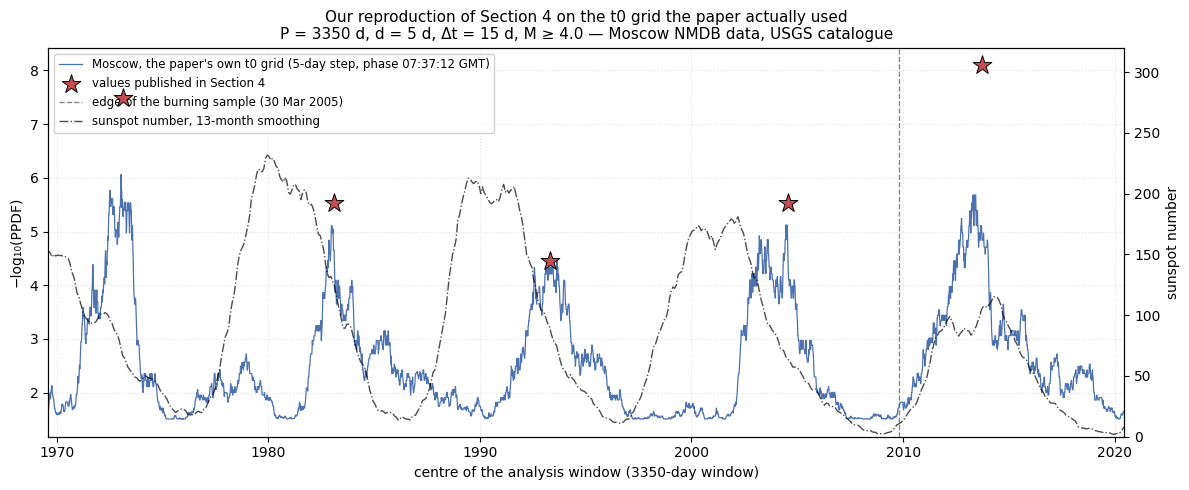

In [9]:
# JEZYK OPISOW NA RYSUNKACH (konwencja z 20260904a.ipynb). Prezentacja jest po
# angielsku; zeby dostac drugi komplet plikow, zmien te stala i uruchom ponownie
# komorki 8, 9 i 10 - nazwy plikow maja przyrostek jezyka, wiec nic sie nie nadpisuje.
JEZYK = "en"

import matplotlib.pyplot as plt

OPISY = {
    "pl": dict(
        os_y="−log₁₀(PPDF)",
        os_x_srodek="środek okna analizy (okno 3350 dni)",
        os_y_plamy="liczba plam słonecznych",
        krzywa="Moskwa, siatka t0 artykułu (co 5 dni, faza 07:37:12 GMT)",
        plamy="plamy słoneczne, wygładzone 13 miesięcy",
        punkty_art="wartości opublikowane w sekcji 4",
        burning="granica „burning sample” (30.03.2005)",
        tytul1=("Nasze odtworzenie sekcji 4 na siatce t0, której używa artykuł\n"
                "P = 3350 dni, d = 5 dni, Δt = 15 dni, M ≥ 4,0 — dane Moskwy z NMDB, "
                "katalog USGS"),
        tytul2=("Pięć opublikowanych punktów sekcji 4 wobec naszej statystyki\n"
                "policzonej w tych samych chwilach t0, co do sekundy"),
        os_x_punkty="−log₁₀(PPDF)",
        leg_pub="artykuł",
        leg_nasze="my, w tej samej dacie",
        leg_6h="my, na siatce 6 h (poprzednie skany)",
        tytul3=("Wrażliwość na fazę kosza: ±5 dni wokół każdej opublikowanej daty\n"
                "krok 6 godzin — dokładnie to dostrajanie, które opisuje podpis Fig. 2"),
        os_x_faza="przesunięcie t0 względem daty artykułu [godziny]",
        leg_data_art="data artykułu",
        leg_wezel="najbliższy węzeł naszej siatki 6 h",
        leg_pub_poziom="wartość opublikowana",
    ),
    "en": dict(
        os_y="−log₁₀(PPDF)",
        os_x_srodek="centre of the analysis window (3350-day window)",
        os_y_plamy="sunspot number",
        krzywa="Moscow, the paper's own t0 grid (5-day step, phase 07:37:12 GMT)",
        plamy="sunspot number, 13-month smoothing",
        punkty_art="values published in Section 4",
        burning="edge of the burning sample (30 Mar 2005)",
        tytul1=("Our reproduction of Section 4 on the t0 grid the paper actually used\n"
                "P = 3350 d, d = 5 d, Δt = 15 d, M ≥ 4.0 — Moscow NMDB data, USGS catalogue"),
        tytul2=("The five published Section-4 points against our statistic\n"
                "evaluated at the same t0, to the second"),
        os_x_punkty="−log₁₀(PPDF)",
        leg_pub="paper",
        leg_nasze="ours, at the same date",
        leg_6h="ours, on the 6 h grid (earlier scans)",
        tytul3=("Sensitivity to bin phase: ±5 days around each published date\n"
                "6-hour steps — exactly the fine tuning the Fig. 2 caption describes"),
        os_x_faza="shift of t0 relative to the paper's date [hours]",
        leg_data_art="the paper's date",
        leg_wezel="nearest node of our 6 h grid",
        leg_pub_poziom="published value",
    ),
}
OP = OPISY[JEZYK]

sunspot = pd.read_csv(SUNSPOT_PATH, sep=";")
sunspot.columns = [c.strip() for c in sunspot.columns]
sunspot["rok_norm"] = sunspot["rok_norm"].astype(float)
sunspot["sunspot"] = sunspot["sunspot"].astype(float)
sunspot = sunspot.sort_values("rok_norm")
sunspot["gladko"] = sunspot["sunspot"].rolling(13, center=True, min_periods=7).mean()


def na_rok(ts):
    ts = pd.Timestamp(ts)
    return ts.year + (ts - pd.Timestamp(f"{ts.year}-01-01")) / pd.Timedelta(days=365.25)


# RYSUNEK 1 - nasza krzywa sekcji 4 na kracie artykulu, z naniesionymi piecioma
# opublikowanymi wartosciami. Jedno kodowanie: wysokosc = sila efektu.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot([na_rok(t) for t in krzywa_art["srodek_okna"]], krzywa_art["neglog10_PPDF"],
        color="#4C72B0", lw=0.9, label=OP["krzywa"], zorder=3)
for _, r in ARTYKUL.iterrows():
    t0 = MIN1_NA_KRACIE if r["nr"] == 1 else r["t0"]
    ax.scatter([na_rok(t0 + pd.Timedelta(days=P_DAYS / 2))], [r["neglog10_PPDF"]],
               marker="*", s=200, color="#C44E52", edgecolor="black", linewidth=0.7, zorder=6,
               label=OP["punkty_art"] if r["nr"] == 1 else None)
ax.axvline(na_rok(BURNING_START + pd.Timedelta(days=P_DAYS / 2)), color="#888888", ls="--", lw=1.0,
           zorder=2, label=OP["burning"])
ax.set_xlabel(OP["os_x_srodek"])
ax.set_ylabel(OP["os_y"])
ax.grid(ls=":", alpha=0.35)

ax2 = ax.twinx()
ax2.plot(sunspot["rok_norm"], sunspot["gladko"], color="black", lw=1.0, ls="-.", alpha=0.7,
         label=OP["plamy"], zorder=1)
ax2.set_ylabel(OP["os_y_plamy"])
ax2.set_ylim(0, 320)

_l1, _e1 = ax.get_legend_handles_labels()
_l2, _e2 = ax2.get_legend_handles_labels()
ax.legend(_l1 + _l2, _e1 + _e2, loc="upper left", fontsize=8.5, framealpha=0.9)
ax.set_title(OP["tytul1"], fontsize=11)
ax.set_xlim(na_rok(krzywa_art["srodek_okna"].min()), na_rok(krzywa_art["srodek_okna"].max()))
fig.tight_layout()
_p = f"{RESULTS_DIR}/replikacja_krzywa_siatka_artykulu_{JEZYK}.png"
fig.savefig(_p, dpi=150)
print(f"Zapisano {_p}")
plt.show()


Zapisano ../results/replikacja_punkty_artykulu_en.png


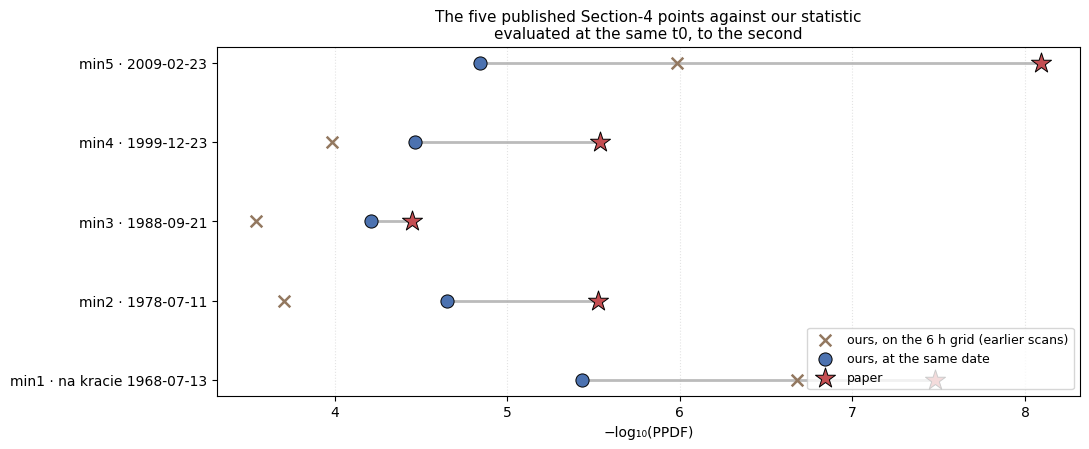

In [10]:
# RYSUNEK 2 - piec opublikowanych punktow wobec naszych, w tych samych chwilach.
# Wykres hantlowy: jedna linia na ere, trzy znaczniki. Jedno kodowanie: pozycja
# w poziomie = sila efektu. Dla min1 pokazujemy wariant lezacy na kracie
# artykulu (1968), bo drukowany rok jest literowka (komorka 3); oba pozostale
# warianty sa w pliku replikacja_punkty_artykulu.csv.
_pokaz = punkty[~punkty["punkt"].str.contains("drukowane|poprawione")].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.6))
_y = np.arange(len(_pokaz))
for i, r in _pokaz.iterrows():
    ax.plot([r["neglog10_nasze_dokladnie"], r["neglog10_opublikowane"]], [i, i],
            color="#BBBBBB", lw=2.0, zorder=1, solid_capstyle="round")
ax.scatter(_pokaz["neglog10_nasza_siatka_6h"], _y, marker="x", s=70, color="#937860",
           linewidth=1.8, zorder=3, label=OP["leg_6h"])
ax.scatter(_pokaz["neglog10_nasze_dokladnie"], _y, marker="o", s=90, color="#4C72B0",
           edgecolor="black", linewidth=0.7, zorder=4, label=OP["leg_nasze"])
ax.scatter(_pokaz["neglog10_opublikowane"], _y, marker="*", s=230, color="#C44E52",
           edgecolor="black", linewidth=0.7, zorder=5, label=OP["leg_pub"])
ax.set_yticks(_y)
ax.set_yticklabels([p.split(" (")[0] + " · " + p.split("(")[1].rstrip(")") for p in _pokaz["punkt"]])
ax.set_xlabel(OP["os_x_punkty"])
ax.grid(ls=":", alpha=0.35, axis="x")
ax.legend(loc="lower right", fontsize=9)
ax.set_title(OP["tytul2"], fontsize=11)
fig.tight_layout()
_p = f"{RESULTS_DIR}/replikacja_punkty_artykulu_{JEZYK}.png"
fig.savefig(_p, dpi=150)
print(f"Zapisano {_p}")
plt.show()


Zapisano ../results/replikacja_faza_binu_en.png


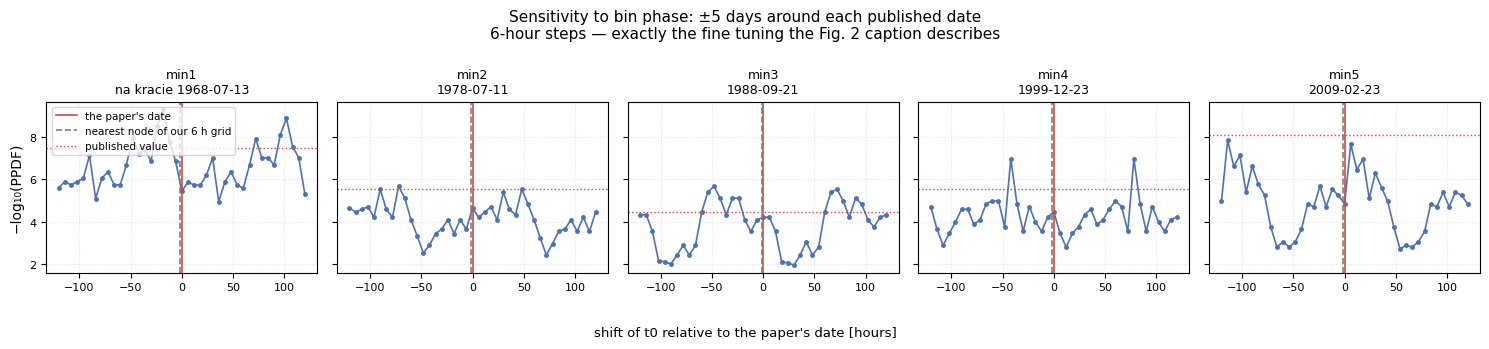

In [11]:
# RYSUNEK 3 - wrazliwosc na faze kosza, jeden panel na ere. Jedno kodowanie:
# wysokosc = sila efektu, os pozioma = przesuniecie w obrebie jednego kosza.
_ery = list(_pokaz["punkt"])
fig, osie = plt.subplots(1, len(_ery), figsize=(3.0 * len(_ery), 3.4), sharey=True)
osie = np.atleast_1d(osie)
for ax, opis in zip(osie, _ery):
    prof = faza[faza["punkt"] == opis]
    r = punkty[punkty["punkt"] == opis].iloc[0]
    ax.plot(prof["przesuniecie_h"], prof["neglog10_PPDF"], color="#4C72B0", lw=1.2,
            marker="o", ms=2.5)
    ax.axvline(0, color="#C44E52", lw=1.2, label=OP["leg_data_art"])
    _dh = (r["t0_nasza_siatka_6h"] - r["t0_artykulu"]) / pd.Timedelta(hours=1)
    ax.axvline(_dh, color="#937860", lw=1.2, ls="--", label=OP["leg_wezel"])
    ax.axhline(r["neglog10_opublikowane"], color="#C44E52", lw=1.0, ls=":",
               label=OP["leg_pub_poziom"])
    ax.set_title(opis.split(" (")[0] + "\n" + opis.split("(")[1].rstrip(")"), fontsize=9)
    ax.grid(ls=":", alpha=0.35)
    ax.tick_params(labelsize=8)
osie[0].set_ylabel(OP["os_y"])
osie[0].legend(fontsize=7.5, loc="upper left")
fig.supxlabel(OP["os_x_faza"], fontsize=9.5)
fig.suptitle(OP["tytul3"], fontsize=11)
fig.tight_layout(rect=(0, 0.02, 1, 0.99))
_p = f"{RESULTS_DIR}/replikacja_faza_binu_{JEZYK}.png"
fig.savefig(_p, dpi=150)
print(f"Zapisano {_p}")
plt.show()


In [12]:
# KOMORKA 11 - PODSUMOWANIE DO DZIENNIKA. Nic nie liczy, tylko zbiera w jednym
# miejscu liczby, ktore maja trafic do 20260905.txt i (po odpaleniu) na slajdy.
print("=" * 78)
print("ODTWORZENIE SEKCJI 4 - PODSUMOWANIE")
print("=" * 78)
print(f"\n1. POWTORKA WYNIKU Z 24.08: minimum {pd.Timestamp(_najlepszy['t0']).date()}, "
      f"PPDF = {_najlepszy['PPDF']:.4e}, sigma = {_najlepszy['sigma']:+.2f}")
print("   Zgodne z 24.08 i z dwoma zapisanymi wczesniej skanami co do 5 cyfr znaczacych.")

print(f"\n2. SIATKA ARTYKULU: krata co {D_DAYS} dni, faza 07:37:12 GMT, "
      f"{len(siatka_art)} punktow na naszym zakresie danych;")
print(f"   nasza dotychczasowa siatka 6 h miala tu {len(siatka_art) * 20} punktow "
      f"- 20 razy wiecej prob niz artykul.")

print("\n3. W OPUBLIKOWANYCH PUNKTACH (roznica dodatnia = jestesmy plytsi):")
for _, r in punkty.iterrows():
    print(f"   {r['punkt']:<30} artykul {r['neglog10_opublikowane']:5.2f} | "
          f"my {r['neglog10_nasze_dokladnie']:5.2f} | roznica {r['roznica_dekad']:+5.2f} | "
          f"na siatce 6 h widzielismy {r['neglog10_nasza_siatka_6h']:5.2f}")

print(f"\n4. FAZA KOSZA: srednia rozpietosc -log10 PPDF w obrebie jednego kosza "
      f"{podsum['rozpietosc_dekad'].mean():.2f} dekady.")

print("\n5. ISTOTNOSC PO KARZE:")
print(istotnosc.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

print("\n6. DWIE IMPLEMENTACJE (komorka 1): rozbieznosc do "
      f"{np.abs(_por['d_neglog10']).max():.3f} dekady na "
      f"{int(((_por['ref_Np'] != _por['szyb_Np']) | (_por['ref_Nvalid'] != _por['szyb_Nvalid'])).sum())}"
      f" z {len(_por)} punktow, zrodlo: remisy na medianie w filtrze rownania (3).")

print("\n7. PLIKI:")
for _f in ["replikacja_powtorka_mosc_2004_2013.csv", "replikacja_punkty_artykulu.csv",
           "replikacja_faza_binu.csv", "replikacja_krzywa_siatka_artykulu_mosc.csv",
           "replikacja_istotnosc_penalizowana.csv",
           f"replikacja_krzywa_siatka_artykulu_{JEZYK}.png",
           f"replikacja_punkty_artykulu_{JEZYK}.png",
           f"replikacja_faza_binu_{JEZYK}.png"]:
    print(f"   {RESULTS_DIR}/{_f}")


ODTWORZENIE SEKCJI 4 - PODSUMOWANIE

1. POWTORKA WYNIKU Z 24.08: minimum 2008-09-27, PPDF = 1.6284e-09, sigma = +5.75
   Zgodne z 24.08 i z dwoma zapisanymi wczesniej skanami co do 5 cyfr znaczacych.

2. SIATKA ARTYKULU: krata co 5 dni, faza 07:37:12 GMT, 3716 punktow na naszym zakresie danych;
   nasza dotychczasowa siatka 6 h miala tu 74320 punktow - 20 razy wiecej prob niz artykul.

3. W OPUBLIKOWANYCH PUNKTACH (roznica dodatnia = jestesmy plytsi):
   min1 (drukowane 1969-07-12)    artykul  7.48 | my  2.17 | roznica +5.31 | na siatce 6 h widzielismy  1.91
   min1 (poprawione 1968-07-12)   artykul  7.48 | my  8.50 | roznica -1.03 | na siatce 6 h widzielismy  6.86
   min1 (na kracie 1968-07-13)    artykul  7.48 | my  5.43 | roznica +2.04 | na siatce 6 h widzielismy  6.68
   min2 (1978-07-11)              artykul  5.52 | my  4.65 | roznica +0.87 | na siatce 6 h widzielismy  3.70
   min3 (1988-09-21)              artykul  4.45 | my  4.21 | roznica +0.24 | na siatce 6 h widzielismy  3.54